In [ ]:
import pandas as pd

ruta = 'base_pecuaria.csv'

base = pd.read_csv(
    ruta,
    encoding='latin1',
    header=[0, 1]
)

# Mostrar las primeras filas
base.head()

,Estado,Leche (miles de litros),Unnamed: 2_level_0,Unnamed: 3_level_0,Carne en canal (toneladas),Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,Unnamed: 10_level_0,Otros productos,Unnamed: 12_level_0,Unnamed: 13_level_0,Unnamed: 14_level_0,AÃ±o,Mes-AÃ±o
,Unnamed: 0_level_1,Bovino,Caprino,Total,Bovino,Porcino,Ovino,Caprino,Ave,Guajolote,Total,Huevo para plato,Miel,Cera en greÃ±a,Lana sucia,Unnamed: 15_level_1,Unnamed: 16_level_1
0,Aguascalientes,38835.07,NaN,38835.07,3051.130,1807.380,77.585,18.373,34956.480,NaN,39910.950,735.495,127.500,NaN,NaN,2025,Diciembre_2025Avance mensual de la producciÃ³n...
1,Baja California,18684.29,37.800,18722.09,6306.560,107.477,30.438,19.215,94.649,NaN,6558.340,2749.220,NaN,NaN,NaN,2025,Diciembre_2025Avance mensual de la producciÃ³n...
2,Baja California Sur,2974.97,394.431,3369.40,584.656,104.940,23.652,43.019,57.269,NaN,813.536,82.483,154.000,4.653,NaN,2025,Diciembre_2025Avance mensual de la producciÃ³n...
3,Campeche,4131.30,3.920,4135.22,2329.770,640.695,182.151,3.999,2702.880,83.071,5942.570,440.349,NaN,NaN,NaN,2025,Diciembre_2025Avance mensual de la producciÃ³n...
4,Coahuila,133611.37,4040.240,137651.62,4980.900,457.487,73.253,323.563,8659.140,NaN,14494.340,5778.160,41.071,0.840,NaN,2025,Diciembre_2025Avance mensual de la producciÃ³n...


In [79]:
# Esto te mostrará una lista de tuplas con los dos niveles de cada columna
print(base.columns.tolist())

[('Estado', 'Unnamed: 0_level_1'), ('Leche (miles de litros)', 'Bovino'), ('Unnamed: 2_level_0', 'Caprino'), ('Unnamed: 3_level_0', 'Total'), ('Carne en canal (toneladas)', 'Bovino'), ('Unnamed: 5_level_0', 'Porcino'), ('Unnamed: 6_level_0', 'Ovino'), ('Unnamed: 7_level_0', 'Caprino'), ('Unnamed: 8_level_0', 'Ave'), ('Unnamed: 9_level_0', 'Guajolote'), ('Unnamed: 10_level_0', 'Total'), ('Otros productos', 'Huevo para plato'), ('Unnamed: 12_level_0', 'Miel'), ('Unnamed: 13_level_0', 'Cera en greÃ±a'), ('Unnamed: 14_level_0', 'Lana sucia'), ('AÃ±o', 'Unnamed: 15_level_1'), ('Mes-AÃ±o', 'Unnamed: 16_level_1')]


In [81]:
import pandas as pd

# 1. Volvemos a leer el archivo pero ignoramos por completo la fila superior de títulos conflictivos.
# Al usar header=1, Pandas usará directamente la segunda fila como los nombres de las columnas.
ruta = 'base_pecuaria.csv'
base = pd.read_csv(
    ruta,
    encoding='latin1',
    header=1  # <--- Cambiamos esto para aplanar desde el inicio
)

# 2. Vamos a ver exactamente cómo llamó Pandas a tus columnas para no errar los nombres
print("Columnas disponibles:")
print(base.columns.tolist())

Columnas disponibles:
['Unnamed: 0_level_1', 'Bovino', 'Caprino', 'Total', 'Bovino.1', 'Porcino', 'Ovino', 'Caprino.1', 'Ave', 'Guajolote', 'Total.1', 'Huevo para plato', 'Miel', 'Cera en greÃ±a', 'Lana sucia', 'Unnamed: 15_level_1', 'Unnamed: 16_level_1']


In [83]:
# 3. Filtramos con los nombres exactos que viste en la lista impresa arriba
# Reemplaza los nombres si aparecen diferentes en tu consola
columnas_interes = ['Unnamed: 0_level_1', 'Huevo para plato', 'Unnamed: 15_level_1', 'Unnamed: 16_level_1'] 

base_filtrada = base[columnas_interes].copy()
base_filtrada.head()

,Unnamed: 0_level_1,Huevo para plato,Unnamed: 15_level_1,Unnamed: 16_level_1
0,Aguascalientes,735.495,2025,Diciembre_2025Avance mensual de la producciÃ³n...
1,Baja California,2749.220,2025,Diciembre_2025Avance mensual de la producciÃ³n...
2,Baja California Sur,82.483,2025,Diciembre_2025Avance mensual de la producciÃ³n...
3,Campeche,440.349,2025,Diciembre_2025Avance mensual de la producciÃ³n...
4,Coahuila,5778.160,2025,Diciembre_2025Avance mensual de la producciÃ³n...


In [84]:
# 1. Renombramos las columnas usando un diccionario
base_filtrada = base_filtrada.rename(columns={
    'Unnamed: 0_level_1': 'Estado',
    'Unnamed: 15_level_1': 'Año',
    'Unnamed: 16_level_1': 'Mes-Año'
})

# 2. Opcional pero muy recomendado:
# Como el "Mes-Año" viene con un texto largo ("Diciembre_2025Avance mensual..."),
# podemos limpiar esa columna para que solo te quede la primera palabra (el mes).
base_filtrada['Mes-Año'] = base_filtrada['Mes-Año'].str.split('_').str[0]

# Ver el resultado final limpio
base_filtrada.head()

,Estado,Huevo para plato,Año,Mes-Año
0,Aguascalientes,735.495,2025,Diciembre
1,Baja California,2749.220,2025,Diciembre
2,Baja California Sur,82.483,2025,Diciembre
3,Campeche,440.349,2025,Diciembre
4,Coahuila,5778.160,2025,Diciembre


In [85]:
# 1. Corregir el nombre de Yucatán en la columna 'Estado'
# Reemplazamos el texto distorsionado 'YucatÃ¡n' por el formato correcto
base_filtrada['Estado'] = base_filtrada['Estado'].replace('YucatÃ¡n', 'Yucatán')

# 2. Definir la lista de los estados que queremos conservar
estados_interes = ['Jalisco', 'Puebla', 'Yucatán', 'Sonora']

# 3. Filtrar el DataFrame usando .isin()
base_filtrada = base_filtrada[base_filtrada['Estado'].isin(estados_interes)].copy()

# Ver el resultado final con los estados seleccionados
base_filtrada

,Estado,Huevo para plato,Año,Mes-Año
170,Jalisco,142072.730000,2025,Diciembre
171,Jalisco,142002.410000,2024,Enero
172,Jalisco,140436.040000,2025,Enero
173,Jalisco,140549.060000,2026,Enero
174,Jalisco,136152.250000,2024,Diciembre
...,...,...,...,...
415,Yucatán,8534.944919,2024,Diciembre
416,Yucatán,12010.294562,2026,Enero
417,Yucatán,9726.478031,2025,Enero
418,Yucatán,13366.198814,2025,Diciembre


In [86]:
# 1. Definimos el orden correcto de los meses del año
orden_meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

# 2. Convertimos la columna 'Mes-Año' en una categoría con el orden cronológico que definimos
base_filtrada['Mes-Año'] = pd.Categorical(base_filtrada['Mes-Año'], categories=orden_meses, ordered=True)

# 3. Ordenamos: primero por Estado (alfabético), luego por Año y finalmente por Mes
base_filtrada = base_filtrada.sort_values(by=['Estado', 'Año', 'Mes-Año']).reset_index(drop=True)

# Ver el resultado final perfectamente ordenado
base_filtrada

,Estado,Huevo para plato,Año,Mes-Año
0,Jalisco,142002.410000,2024,Enero
1,Jalisco,145032.025537,2024,Enero
2,Jalisco,138725.608267,2024,Enero
3,Jalisco,135187.305346,2024,Enero
4,Jalisco,147547.991504,2024,Enero
...,...,...,...,...
245,Yucatán,12100.711076,2026,Enero
246,Yucatán,12152.209091,2026,Enero
247,Yucatán,12395.116394,2026,Enero
248,Yucatán,12415.681120,2026,Enero


In [88]:
base_filtrada.shape

(250, 4)

In [87]:
base_filtrada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Estado            250 non-null    object  
 1   Huevo para plato  250 non-null    float64 
 2   Año               250 non-null    int64   
 3   Mes-Año           250 non-null    category
dtypes: category(1), float64(1), int64(1), object(1)
memory usage: 6.6+ KB


In [89]:
# Eliminamos filas con nulos y sobreescribimos el DataFrame
base_filtrada = base_filtrada.dropna()

# Verificamos cuántos datos nos quedaron después de la limpieza
print(f"Total de filas limpias: {len(base_filtrada)}")

Total de filas limpias: 250


In [90]:
base_filtrada.isnull().sum()

Estado              0
Huevo para plato    0
Año                 0
Mes-Año             0
dtype: int64

In [15]:
!pip install seaborn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


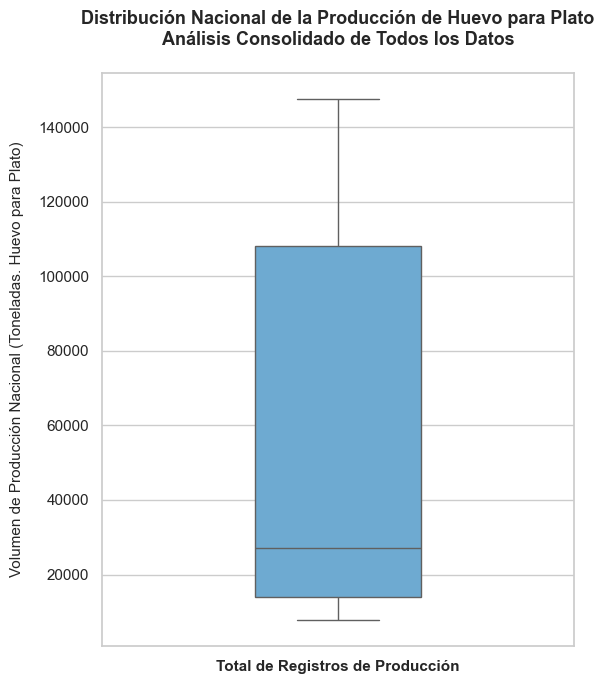

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño del gráfico (un formato vertical u sutil va mejor para una sola caja)
plt.figure(figsize=(6, 7))
sns.set_theme(style="whitegrid")

# 2. Crear el Boxplot global
# Al pasar todo el DataFrame a 'y' sin definir un 'x', se unifican todos los datos
sns.boxplot(
    y='Huevo para plato', 
    data=base_filtrada, 
    color='#5dade2',     # Un color azul claro y limpio
    width=0.35,          # Estilizamos el ancho de la caja
    fliersize=7,         # Tamaño de los puntos de anomalías
    flierprops={'markerfacecolor': '#e74c3c', 'markeredgecolor': 'black', 'marker': 'o'} # Anomalías en rojo
)

# 3. Personalizar títulos y etiquetas
plt.title('Distribución Nacional de la Producción de Huevo para Plato\nAnálisis Consolidado de Todos los Datos', fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Volumen de Producción Nacional (Toneladas. Huevo para Plato)', fontsize=11, labelpad=10)

# Etiqueta central en el eje X para dar contexto
plt.xlabel('Total de Registros de Producción', fontsize=11, fontweight='bold', labelpad=10)
plt.xticks([]) # Limpiamos marcas innecesarias en el eje X

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

In [92]:
import numpy as np

def eliminar_outliers_iqr(df, columna_valor, columna_grupo):
    df_limpio = pd.DataFrame()
    outliers_detectados = 0
    
    # Analizamos estado por estado para no mezclar los volúmenes de producción
    for grupo, sub_df in df.groupby(columna_grupo):
        Q1 = sub_df[columna_valor].quantile(0.25)
        Q3 = sub_df[columna_valor].quantile(0.75)
        IQR = Q3 - Q1
        
        # Definimos límites tolerables (1.5 es el estándar de la industria)
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        # Filtramos los datos que están dentro del rango correcto
        datos_normales = sub_df[(sub_df[columna_valor] >= limite_inferior) & (sub_df[columna_valor] <= limite_superior)]
        df_limpio = pd.concat([df_limpio, datos_normales], axis=0)
        
        # Contamos cuántas anomalías quitamos en este estado
        outliers_detectados += len(sub_df) - len(datos_normales)
        print(f"Estado: {grupo} | Límites: [{limite_inferior:.2f} a {limite_superior:.2f}] | Anomalías eliminadas: {len(sub_df) - len(datos_normales)}")
        
    print(f"\n¡Limpieza completada! Se eliminaron {outliers_detectados} anomalías en total.")
    return df_limpio.reset_index(drop=True)

# Aplicamos la función a tu base de datos
base_sin_anomalias = eliminar_outliers_iqr(base_filtrada, 'Huevo para plato', 'Estado')

Estado: Jalisco | Límites: [127307.44 a 151154.10] | Anomalías eliminadas: 0
Estado: Puebla | Límites: [33486.04 a 45312.99] | Anomalías eliminadas: 0
Estado: Sonora | Límites: [12846.03 a 18286.80] | Anomalías eliminadas: 0
Estado: Yucatán | Límites: [4816.56 a 16971.83] | Anomalías eliminadas: 0

¡Limpieza completada! Se eliminaron 0 anomalías en total.


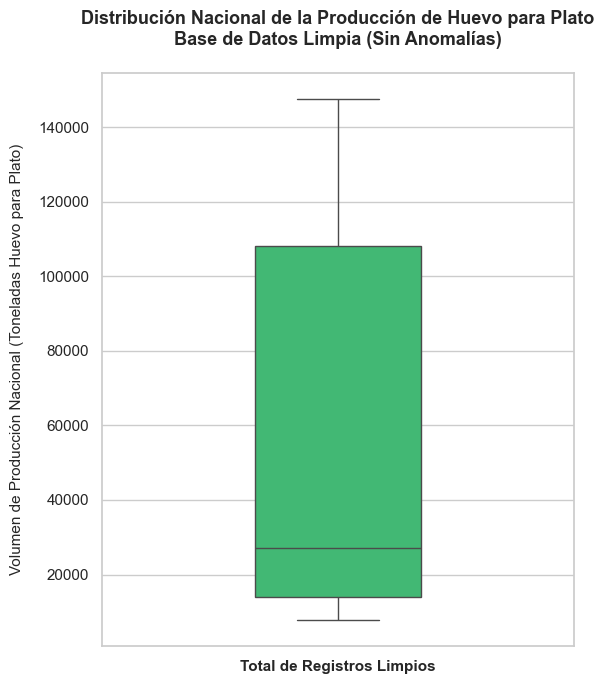

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño del gráfico
plt.figure(figsize=(6, 7))
sns.set_theme(style="whitegrid")

# 2. Crear el Boxplot global SIN anomalías
# Usamos 'base_sin_anomalias' como fuente de datos
sns.boxplot(
    y='Huevo para plato', 
    data=base_sin_anomalias,  # <--- Aquí hacemos el cambio a la base limpia
    color='#2ecc71',          # Color verde para indicar que la base está limpia
    width=0.35,               # Mantenemos el diseño esbelto
    fliersize=7,
    flierprops={'markerfacecolor': "#3cbfe7", 'markeredgecolor': 'black', 'marker': 'o'}
)

# 3. Personalizar títulos y etiquetas
plt.title('Distribución Nacional de la Producción de Huevo para Plato\nBase de Datos Limpia (Sin Anomalías)', fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Volumen de Producción Nacional (Toneladas Huevo para Plato)', fontsize=11, labelpad=10)

# Etiqueta de contexto abajo
plt.xlabel('Total de Registros Limpios', fontsize=11, fontweight='bold', labelpad=10)
plt.xticks([]) # Limpiamos el eje X

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

In [94]:
base_sin_anomalias.to_csv('produccion_limpios_sin_anomalias.csv', index=False, encoding='utf-8-sig')

print("¡Archivo guardado con éxito!")

¡Archivo guardado con éxito!


In [64]:
import pandas as pd

# Al estar en la misma carpeta, solo necesitas poner el nombre del archivo
ruta = 'precios_huevo_consolidado_2024_2026.csv'

# Cargamos la base de datos con tus configuraciones originales
df = pd.read_csv(
    ruta,
    encoding='latin1',
    header=[0, 1]
)

# Mostrar las primeras filas
df.head()

,ï»¿Fecha,Producto,Tipo de Venta,Precio Frecuente,Precio Minimo,Precio Maximo,Estado,Central de Abasto
,03/01/2024,Huevo blanco,Mayoreo,31.0,Unnamed: 4_level_1,Unnamed: 5_level_1,JAL,Mercado de Abasto de Guadalajara
0,03/01/2024,Huevo blanco,Medio Mayoreo,31.5,NaN,NaN,JAL,Mercado de Abasto de Guadalajara
1,03/01/2024,Huevo blanco,Menudeo,32.0,NaN,NaN,JAL,Mercado de Abasto de Guadalajara
2,10/01/2024,Huevo blanco,Mayoreo,30.0,NaN,NaN,JAL,Mercado de Abasto de Guadalajara
3,17/01/2024,Huevo blanco,Mayoreo,32.0,NaN,NaN,JAL,Mercado de Abasto de Guadalajara
4,24/01/2024,Huevo blanco,Mayoreo,38.0,NaN,NaN,JAL,Mercado de Abasto de Guadalajara


In [65]:
print(df.columns.tolist())

[('ï»¿Fecha', '03/01/2024'), ('Producto', 'Huevo blanco'), ('Tipo de Venta', 'Mayoreo'), ('Precio Frecuente', '31.0'), ('Precio Minimo', 'Unnamed: 4_level_1'), ('Precio Maximo', 'Unnamed: 5_level_1'), ('Estado', 'JAL'), ('Central de Abasto', 'Mercado de Abasto de Guadalajara')]


In [66]:
import pandas as pd

# 1. Volvemos a leer el archivo usando 'utf-8-sig'
# Esto elimina automáticamente los símbolos raros 'ï»¿' del inicio
ruta_nuevo_archivo = 'precios_huevo_consolidado_2024_2026.csv'  # Pon aquí la ruta de tu archivo
df = pd.read_csv(ruta_nuevo_archivo, encoding='utf-8-sig')

# 2. Si el archivo viene con doble nivel de títulos, lo aplanamos al nivel inferior
df.columns = df.columns.get_level_values(df.columns.nlevels - 1)

# 3. Definimos la lista con las mayúsculas EXACTAS que vienen en el archivo
columnas_nuevas = ['Fecha', 'Producto', 'Precio Frecuente', 'Estado']

# 4. Filtramos el DataFrame
df_resultado = df[columnas_nuevas].copy()

# 5. Mostramos el resultado limpio
df_resultado

,Fecha,Producto,Precio Frecuente,Estado
0,03/01/2024,Huevo blanco,31.0,JAL
1,03/01/2024,Huevo blanco,31.5,JAL
2,03/01/2024,Huevo blanco,32.0,JAL
3,10/01/2024,Huevo blanco,30.0,JAL
4,17/01/2024,Huevo blanco,32.0,JAL
...,...,...,...,...
220,21/01/2026,Huevo blanco,32.0,YUC
221,21/01/2026,Huevo blanco,42.0,YUC
222,28/01/2026,Huevo blanco,30.0,YUC
223,28/01/2026,Huevo blanco,32.0,YUC


In [67]:
df_resultado.shape

(225, 4)

In [68]:
df_resultado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Fecha             225 non-null    object 
 1   Producto          225 non-null    object 
 2   Precio Frecuente  225 non-null    float64
 3   Estado            225 non-null    object 
dtypes: float64(1), object(3)
memory usage: 7.2+ KB


In [69]:
# Eliminamos filas con nulos y sobreescribimos el DataFrame
df_resultado = df_resultado.dropna()

# Verificamos cuántos datos nos quedaron después de la limpieza
print(f"Total de filas limpias: {len(df_resultado)}")

Total de filas limpias: 225


In [70]:
# Cuenta cuántos valores nulos quedan por columna
df_resultado.isnull().sum()

Fecha               0
Producto            0
Precio Frecuente    0
Estado              0
dtype: int64

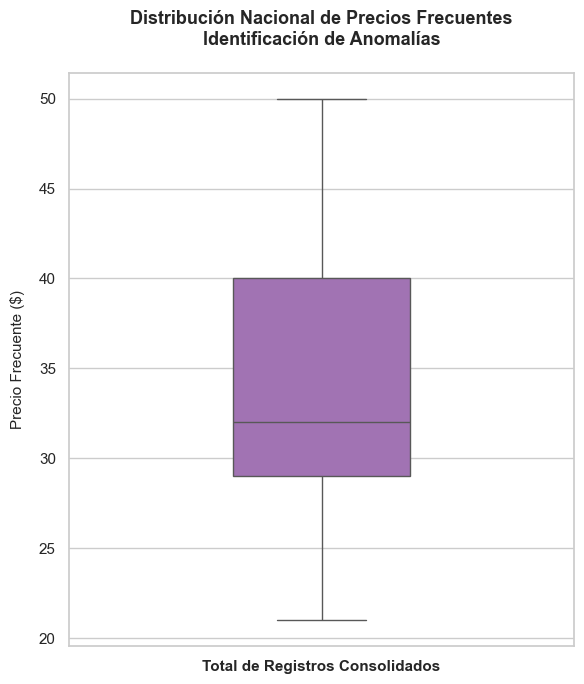

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo y tamaño del gráfico
plt.figure(figsize=(6, 7))
sns.set_theme(style="whitegrid")

# 2. Crear el Boxplot global para el Precio Frecuente
sns.boxplot(
    y='Precio Frecuente', 
    data=df_resultado, 
    color='#a569bd',     # Color morado elegante
    width=0.35,
    fliersize=7,
    flierprops={'markerfacecolor': '#e74c3c', 'markeredgecolor': 'black', 'marker': 'o'} # Anomalías en rojo
)

# 3. Personalizar títulos y etiquetas
plt.title('Distribución Nacional de Precios Frecuentes\nIdentificación de Anomalías', fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Precio Frecuente ($)', fontsize=11, labelpad=10)
plt.xlabel('Total de Registros Consolidados', fontsize=11, fontweight='bold', labelpad=10)
plt.xticks([]) # Limpiamos el eje X

plt.tight_layout()
plt.show()

In [72]:
import pandas as pd

# 1. Creamos una base vacía para almacenar los datos limpios
df_limpio_precios = pd.DataFrame()
total_anomalias = 0

# 2. Agrupamos por Estado para calcular los límites específicos de cada región
for estado, sub_df in df_resultado.groupby('Estado'):
    Q1 = sub_df['Precio Frecuente'].quantile(0.25)
    Q3 = sub_df['Precio Frecuente'].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites estándar de la industria (1.5 * IQR)
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Filtramos los datos que están dentro del rango correcto
    datos_normales = sub_df[(sub_df['Precio Frecuente'] >= limite_inferior) & (sub_df['Precio Frecuente'] <= limite_superior)]
    
    # Unimos al nuevo DataFrame limpio
    df_limpio_precios = pd.concat([df_limpio_precios, datos_normales], axis=0)
    
    # Conteo de anomalías eliminadas en este estado
    anomalias_estado = len(sub_df) - len(datos_normales)
    total_anomalias += anomalias_estado
    
    if anomalias_estado > 0:
        print(f"Estado: {estado} | Límites: [{limite_inferior:.2f} a {limite_superior:.2f}] | Anomalías quitadas: {anomalias_estado}")

print(f"\n¡Limpieza concluida! Se eliminaron {total_anomalias} anomalías en total.")
print(f"Filas originales: {len(df_resultado)} -> Filas limpias finales: {len(df_limpio_precios)}")

# Resetear los índices para que queden consecutivos
df_limpio_precios = df_limpio_precios.reset_index(drop=True)

Estado: JAL | Límites: [18.50 a 38.50] | Anomalías quitadas: 5
Estado: SLP | Límites: [20.38 a 39.38] | Anomalías quitadas: 2

¡Limpieza concluida! Se eliminaron 7 anomalías en total.
Filas originales: 225 -> Filas limpias finales: 218


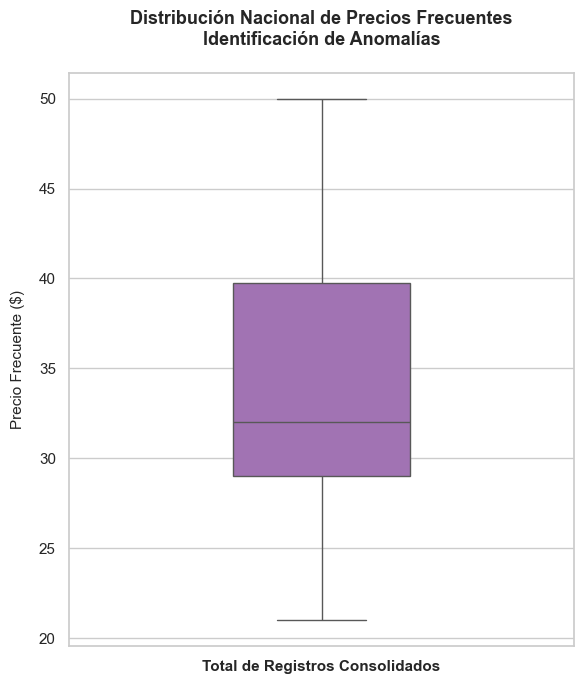

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo y tamaño del gráfico
plt.figure(figsize=(6, 7))
sns.set_theme(style="whitegrid")

# 2. Crear el Boxplot global para el Precio Frecuente
sns.boxplot(
    y='Precio Frecuente', 
    data=df_limpio_precios, 
    color="#fc0d0d",     # Color morado elegante
    width=0.35,
    fliersize=7,
    flierprops={'markerfacecolor': '#e74c3c', 'markeredgecolor': 'black', 'marker': 'o'} # Anomalías en rojo
)

# 3. Personalizar títulos y etiquetas
plt.title('Distribución Nacional de Precios Frecuentes\nIdentificación de Anomalías', fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Precio Frecuente ($)', fontsize=11, labelpad=10)
plt.xlabel('Total de Registros Consolidados', fontsize=11, fontweight='bold', labelpad=10)
plt.xticks([]) # Limpiamos el eje X

plt.tight_layout()
plt.show()

In [77]:
# Guardar el DataFrame limpio en un nuevo archivo CSV
df_limpio_precios.to_csv('precios_limpios_sin_anomalias.csv', index=False, encoding='utf-8-sig')

print("¡Archivo guardado con éxito!")

¡Archivo guardado con éxito!
